In [41]:
import sys
print(sys.executable)

/Users/yasmine/venv-metal/bin/python


In [6]:
from zipfile import ZipFile
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
with ZipFile("carplates.zip","r") as z:
    for name in z.namelist():
        print(name)

In [ ]:
extract_path = "datasets"
with ZipFile("carplates.zip","r") as z:
    z.extractall(path=extract_path)

In [ ]:
root = Path("datasets/License-Plate-Data")

train_images_dir = root / "train" / "images"
train_labels_dir = root / "train" / "labels"

test_images_dir = root / "test" / "images"
test_labels_dir = root / "test" / "labels"

yaml_path = root / "data.yaml"

In [ ]:
for p in [train_images_dir, train_labels_dir, test_images_dir, test_labels_dir, yaml_path]:
    print(p, "->", p.exists())

In [ ]:
train_images = sorted(train_images_dir.glob("*.png"))
train_labels = sorted(train_labels_dir.glob("*.txt"))

test_images = sorted(test_images_dir.glob("*.png"))
test_labels = sorted(test_labels_dir.glob("*.txt"))

print("Train images :", len(train_images))
print("Train labels :", len(train_labels))
print("Test images  :", len(test_images))
print("Test labels  :", len(test_labels))

In [ ]:
train_image_stems = {p.stem for p in train_images}
train_label_stems = {p.stem for p in train_labels}

test_image_stems = {p.stem for p in test_images}
test_label_stems = {p.stem for p in test_labels}

print("Train - images sans label :", len(train_image_stems - train_label_stems))
print("Train - labels sans image :", len(train_label_stems - train_image_stems))

print("Test - images sans label  :", len(test_image_stems - test_label_stems))
print("Test - labels sans image  :", len(test_label_stems - test_image_stems))

In [ ]:
for img_path in train_images[:5]:
    label_path = train_labels_dir / f"{img_path.stem}.txt"
    print("Image :", img_path.name)
    print("Label :", label_path.name, "| existe :", label_path.exists())
    print("-" * 30)

In [ ]:
def load_image_rgb(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [ ]:
sample_img = train_images[0]
img = load_image_rgb(sample_img)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(sample_img.name)
plt.axis("off")
plt.show()

In [ ]:
sample_paths = random.sample(train_images, k=min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_paths):
    img = load_image_rgb(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

def quick_view(img_path):
    img_path = Path(img_path)

    # trouver le label associé
    label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")

    print("Image :", img_path)
    print("Label :", label_path)

    # afficher contenu du label
    if label_path.exists():
        with open(label_path, "r") as f:
            print("\nContenu label.txt :")
            print(f.read())
    else:
        print(" pas de label")

    # afficher image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [ ]:
quick_view("datasets/License-Plate-Data/train/images/Cars277.png")

In [ ]:
def read_yolo_label(label_path):
    rows = []
    
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            if len(parts) != 5:
                raise ValueError(f"Ligne invalide dans {label_path}: {line}")
            
            class_id, x_center, y_center, width, height = map(float, parts)
            rows.append({
                "class_id": int(class_id),
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })
    
    return rows

In [ ]:
sample_label = train_labels[0]
label_data = read_yolo_label(sample_label)

print("Fichier :", sample_label.name)
print("Contenu parsé :")
for row in label_data:
    print(row)

In [ ]:
with open(sample_label, "r") as f:
    print(f.read())

In [ ]:
def yolo_to_xyxy(box, img_width, img_height):
    x_center = box["x_center"] * img_width
    y_center = box["y_center"] * img_height
    width = box["width"] * img_width
    height = box["height"] * img_height

    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2

    return int(x_min), int(y_min), int(x_max), int(y_max)

In [ ]:
def draw_boxes(image, boxes, class_names=None):
    image_copy = image.copy()
    h, w = image_copy.shape[:2]

    for box in boxes:
        x_min, y_min, x_max, y_max = yolo_to_xyxy(box, w, h)

        cv2.rectangle(image_copy, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

        class_id = box["class_id"]
        label = str(class_id)
        if class_names is not None and class_id < len(class_names):
            label = class_names[class_id]

        cv2.putText(
            image_copy,
            label,
            (x_min, max(20, y_min - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    return image_copy

In [ ]:
sample_img = train_images[201]
sample_label = train_labels_dir / f"{sample_img.stem}.txt"

img = load_image_rgb(sample_img)
boxes = read_yolo_label(sample_label)
img_boxed = draw_boxes(img, boxes, class_names=["license_plate"])

plt.figure(figsize=(10, 7))
plt.imshow(img_boxed)
plt.title(sample_img.name)
plt.axis("off")
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install ultralytics

In [ ]:

root = Path("datasets/License-Plate-Data").resolve()

new_yaml = f"""
train: {root}/train/images
val: {root}/test/images

nc: 1
names: ['license_plate']
"""

Path("datasets/License-Plate-Data/data.yaml").write_text(new_yaml)

In [ ]:
yaml_path = Path("datasets/License-Plate-Data/data.yaml")

content = yaml_path.read_text()
print(content)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # modèle petit

model.train(
    data="datasets/License-Plate-Data/data.yaml",
    epochs=20,
    imgsz=640,
    batch=4,
    device="mps"  # ou rien si bug
)

In [ ]:
model.model

In [1]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-3/weights/best.pt")

results = model("datasets/License-Plate-Data/test/images/Cars2.png")
print("done")
print(results[0].boxes)


image 1/1 /Users/yasmine/Documents/yolo/datasets/License-Plate-Data/test/images/Cars2.png: 640x640 1 license_plate, 25.9ms
Speed: 1.4ms preprocess, 25.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
done
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.])
conf: tensor([0.6607])
data: tensor([[229.0487, 173.0109, 269.4536, 193.2000,   0.6607,   0.0000]])
id: None
is_track: False
orig_shape: (400, 400)
shape: torch.Size([1, 6])
xywh: tensor([[249.2511, 183.1055,  40.4048,  20.1891]])
xywhn: tensor([[0.6231, 0.4578, 0.1010, 0.0505]])
xyxy: tensor([[229.0487, 173.0109, 269.4536, 193.2000]])
xyxyn: tensor([[0.5726, 0.4325, 0.6736, 0.4830]])


In [5]:
model.predict(
    "datasets/License-Plate-Data/test/images/Cars12.png",
    show=True
)


image 1/1 /Users/yasmine/Documents/yolo/datasets/License-Plate-Data/test/images/Cars12.png: 256x640 1 license_plate, 29.2ms
Speed: 2.0ms preprocess, 29.2ms inference, 0.4ms postprocess per image at shape (1, 3, 256, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'license_plate'}
 obb: None
 orig_img: array([[[ 36,  52,  64],
         [ 33,  49,  64],
         [ 25,  35,  46],
         ...,
         [  7,   5,   8],
         [ 10,   9,  14],
         [ 15,  10,  19]],
 
        [[ 32,  46,  56],
         [ 38,  53,  66],
         [ 35,  45,  59],
         ...,
         [  4,   4,   7],
         [  9,  10,  15],
         [ 15,  12,  20]],
 
        [[ 33,  43,  52],
         [ 35,  46,  58],
         [ 39,  48,  60],
         ...,
         [  6,   5,   7],
         [  8,  10,  16],
         [ 13,  12,  20]],
 
        ...,
 
        [[  5,   5,   3],
         [ 81,  81,  79],
         [ 93,  93,  92],
         ...,
         [ 34,  51,  60],
         [ 59,  77,  88],
         [ 95, 115, 132]],
 
        [[  4,   4,   3],
         [ 35,  35,  34],
         [ 44,  44,  42],
         ...,
         [ 


image 1/1 /Users/yasmine/Documents/yolo/datasets/License-Plate-Data/test/images/Cars157.png: 448x640 1 license_plate, 21.1ms
Speed: 1.0ms preprocess, 21.1ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)


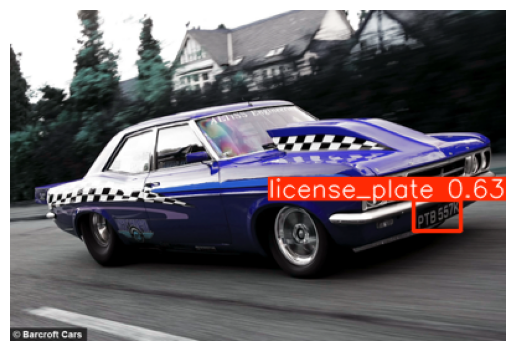

In [11]:
import matplotlib.pyplot as plt

model = YOLO("runs/detect/train-3/weights/best.pt")

results = model("datasets/License-Plate-Data/test/images/Cars157.png")

img = results[0].plot()  # image avec boxes

plt.imshow(img)
plt.axis("off")
plt.show()

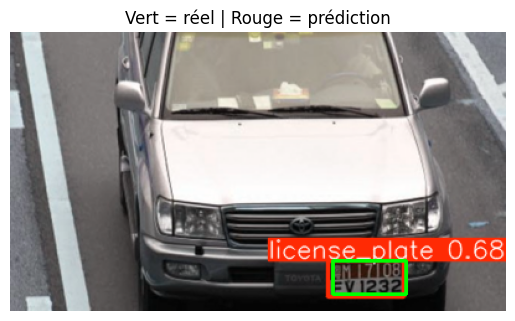

In [36]:
img_path = Path("datasets/License-Plate-Data/test/images/Cars135.png")

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

results = model(str(img_path))
img_pred = results[0].plot()

label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")

with open(label_path) as f:
    for line in f:
        _, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img_pred, (x1, y1), (x2, y2), (0,255,0), 2)

plt.imshow(img_pred)
plt.title("Vert = réel | Rouge = prédiction")
plt.axis("off")
plt.show()

In [55]:
results[0].boxes.conf

tensor([0.6804])

In [72]:
def extract_plate(img_org, bounding_box, save_path=None, show=True):
    """
    img_org: image PIL déjà ouverte
    bounding_box: (x1, y1, x2, y2)
    save_path: chemin où sauvegarder l'image extraite
    show: afficher ou non dans Jupyter

    return: image PIL cropée
    """
    x1, y1, x2, y2 = map(int, bounding_box)

    # sécuriser les coordonnées
    w, h = img_org.size
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    # crop
    plate = img_org.crop((x1, y1, x2, y2))

    # affichage inline Jupyter
    if show:
        plt.figure(figsize=(4, 2))
        plt.imshow(plate)
        plt.axis("off")
        plt.title("Extracted plate")
        plt.show()

    # sauvegarde
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plate.save(save_path)

    return plate

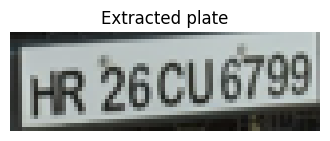

In [73]:
img_path = "datasets/License-Plate-Data/test/images/Cars77.png"
img = Image.open(img_path)

results = model(img_path)
boxes = results[0].boxes.xyxy.cpu().numpy()

# prendre la première plaque détectée
plate = extract_plate(
    img_org=img,
    bounding_box=boxes[0],
    save_path="extracted_plates/Cars77_plate.png",
    show=True
)

In [46]:
!{sys.executable} -m pip install rapidocr onnxruntime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 8.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 5.5 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.7 MB/s  0:00:00 eta 0:00:01
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144590 sha256=ecc32aa1680fd11c1babf13e7eeec24dbd93f7be2fc15cb97c5992c5ee8530cb
  Stored in directory: /Users/yasmine/Library/Caches/pip/wheels/1a/97/32/461f837398029ad76911109f07047fde1d7b661a147c7c56d1
Successfully built antlr4-python3-runtime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [rapidocr]6/7 [rapidocr]me]


In [79]:
from rapidocr import RapidOCR

engine = RapidOCR()

img_url = "extracted_plates/Cars77_plate.png"

result = engine(img_url)
print(result.txts)


[INFO] 2026-04-22 22:54:56,656 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-22 22:54:56,661 [RapidOCR] download_file.py:60: File exists and is valid: /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-22 22:54:56,661 [RapidOCR] main.py:57: Using /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-22 22:54:56,688 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-22 22:54:56,690 [RapidOCR] download_file.py:60: File exists and is valid: /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-22 22:54:56,690 [RapidOCR] main.py:57: Using /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-22 22:54:56,705 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-22 22:54:56,711 [R

('HR26CU6799',)
